# Explore raw market data

Scratch notebook for poking at the raw parquet streams (BBO `front_levels`, `trade`, funding `fri`)
straight off disk. Reads via `boba.io` loaders only — **no dataset/feature classes**, so what you
see here is exactly what the ETL ingests.

Data is organised in ~24h **blocks** (`holocron.{ts}.{idx}`) per **listing** token
(e.g. `bin_doge_usdt_p`). The data root comes from `data_dir` in `settings.local.toml`.

In [9]:
import polars as pl

from boba.io import DATA_DIR, list_blocks, load_block

pl.Config.set_tbl_rows(12)
print("DATA_DIR:", DATA_DIR)

DATA_DIR: /Users/leith/claude/bob/mando_data/corelliantkdata1/holocron


## What's on disk

Each file is `holocron.{ts}.{idx}.{listing}.{data_type}.parquet`. Enumerate the available
listing tokens, then the blocks present for one of them.

In [10]:
listings = sorted({".".join(f.name.split(".")[3:-2])
                   for f in DATA_DIR.glob("holocron.*.front_levels.parquet")})
print(f"{len(listings)} listings:")
print("  " + "\n  ".join(listings))

24 listings:
  bin_bnb_usdt
  bin_bnb_usdt_p
  bin_btc_usdt
  bin_btc_usdt_p
  bin_doge_usdt
  bin_doge_usdt_p
  bin_eth_usdt
  bin_eth_usdt_p
  byb_bnb_usdt
  byb_bnb_usdt_p
  byb_btc_usdt
  byb_btc_usdt_p
  byb_doge_usdt
  byb_doge_usdt_p
  byb_eth_usdt
  byb_eth_usdt_p
  okx_bnb_usdt
  okx_bnb_usdt_p
  okx_btc_usdt
  okx_btc_usdt_p
  okx_doge_usdt
  okx_doge_usdt_p
  okx_eth_usdt
  okx_eth_usdt_p


In [11]:
LISTING = "bin_doge_usdt_p"

blocks = list_blocks(LISTING, "front_levels")
print(f"{len(blocks)} blocks for {LISTING}; using the first one")
BLOCK = blocks[0]
BLOCK

58 blocks for bin_doge_usdt_p; using the first one


'holocron.20260520T135822.0'

## BBO (`front_levels`)

Best bid/ask snapshots. `rx_time` is our receive clock (ns, UTC); `exchange_time` is the venue
clock — the gap is feed latency. Prices/qtys are float64.

In [12]:
fl = load_block(BLOCK, LISTING, "front_levels").sort("rx_time")
print(fl.shape)
fl.head()

(5679487, 11)


event_id,start_poll_duration_since_start_app_ns,rx_time,exchange_code,contract_code,exchange_time,seq,bid_prc,bid_qty,ask_prc,ask_qty
i64,i64,"datetime[ns, UTC]",cat,cat,"datetime[ns, UTC]",i64,f64,f64,f64,f64
964,4207226590,2026-05-20 13:58:26.305132581 UTC,"""BIN""","""DOGE/USDT+P""",2026-05-20 13:58:26.304 UTC,10590175334750,0.10352,272138.0,0.10353,243136.0
966,4209214048,2026-05-20 13:58:26.307117162 UTC,"""BIN""","""DOGE/USDT+P""",2026-05-20 13:58:26.306 UTC,10590175335175,0.10352,287185.0,0.10353,243136.0
969,4215575575,2026-05-20 13:58:26.313477020 UTC,"""BIN""","""DOGE/USDT+P""",2026-05-20 13:58:26.312 UTC,10590175335978,0.10352,287184.0,0.10353,243136.0
1094,4383334241,2026-05-20 13:58:26.481236275 UTC,"""BIN""","""DOGE/USDT+P""",2026-05-20 13:58:26.480 UTC,10590175351228,0.10352,287184.0,0.10353,237758.0
1145,4474943390,2026-05-20 13:58:26.572845262 UTC,"""BIN""","""DOGE/USDT+P""",2026-05-20 13:58:26.571 UTC,10590175365185,0.10352,287184.0,0.10353,311846.0


In [13]:
# Mid + spread, downsampled to ~1s so it's plottable without choking on millions of rows.
mid = (
    fl.select(
        "rx_time",
        ((pl.col("bid_prc") + pl.col("ask_prc")) / 2).alias("mid"),
        (pl.col("ask_prc") - pl.col("bid_prc")).alias("spread"),
    )
    .group_by_dynamic("rx_time", every="1s")
    .agg(pl.col("mid").last(), pl.col("spread").mean())
)
mid.head()

rx_time,mid,spread
"datetime[ns, UTC]",f64,f64
2026-05-20 13:58:26 UTC,0.103525,0.00001
2026-05-20 13:58:27 UTC,0.103525,0.00001
2026-05-20 13:58:28 UTC,0.103525,0.00001
2026-05-20 13:58:29 UTC,0.103525,0.00001
2026-05-20 13:58:30 UTC,0.103525,0.00001


## Trades (`trade`)

`aggressor` is `Bid`/`Ask` (taker side); the dataset maps `Bid → +1`, `Ask → -1`.

In [14]:
td = load_block(BLOCK, LISTING, "trade").sort("rx_time")
print(td.shape)
td.select("rx_time", "exchange_time", "aggressor", "prc", "qty").head()

(1000046, 13)


rx_time,exchange_time,aggressor,prc,qty
"datetime[ns, UTC]","datetime[ns, UTC]",cat,f64,f64
2026-05-20 13:58:27.865967370 UTC,2026-05-20 13:58:27.865 UTC,"""Ask""",0.10352,1631.0
2026-05-20 13:58:29.115063957 UTC,2026-05-20 13:58:29.114 UTC,"""Bid""",0.10353,55.0
2026-05-20 13:58:29.115063957 UTC,2026-05-20 13:58:29.114 UTC,"""Bid""",0.10353,54.0
2026-05-20 13:58:29.115063957 UTC,2026-05-20 13:58:29.114 UTC,"""Bid""",0.10353,182.0
2026-05-20 13:58:31.073296592 UTC,2026-05-20 13:58:31.072 UTC,"""Ask""",0.10352,49.0


In [15]:
# Signed volume by taker side.
td.group_by("aggressor").agg(
    pl.len().alias("n_trades"),
    pl.col("qty").sum().alias("total_qty"),
)

aggressor,n_trades,total_qty
cat,u32,f64
"""Ask""",498697,2.2218e9
"""Bid""",501349,2.1341e9


## Funding (`fri`)

Indicative funding rate + next funding time (perp listings only).

In [16]:
# fri is sparse and its block ids don't line up 1:1 with front_levels (it often
# lacks the first block), so resolve a block from the fri stream itself.
fri_blocks = list_blocks(LISTING, "fri")
assert fri_blocks, f"No funding (fri) stream for {LISTING} (spot listings have none)."
fri_block = BLOCK if BLOCK in set(fri_blocks) else fri_blocks[0]
if fri_block != BLOCK:
    print(f"note: block {BLOCK!r} has no fri data; using {fri_block!r}")
fri = load_block(fri_block, LISTING, "fri").sort("rx_time")
print(fri.shape)
fri.select("rx_time", "indicative_funding_rate", "next_funding_time").head()

note: block 'holocron.20260520T135822.0' has no fri data; using 'holocron.20260520T135822.1'
(86398, 9)


rx_time,indicative_funding_rate,next_funding_time
"datetime[ns, UTC]",f64,"datetime[ns, UTC]"
2026-05-21 13:58:23.054162028 UTC,3.2000e-7,2026-05-21 16:00:00 UTC
2026-05-21 13:58:24.053691303 UTC,3.2000e-7,2026-05-21 16:00:00 UTC
2026-05-21 13:58:25.058978120 UTC,3.2000e-7,2026-05-21 16:00:00 UTC
2026-05-21 13:58:26.066787280 UTC,3.2000e-7,2026-05-21 16:00:00 UTC
2026-05-21 13:58:27.061113086 UTC,3.2000e-7,2026-05-21 16:00:00 UTC


## Quick plot

Requires `matplotlib` in the env (see `notebooks/README.md`).

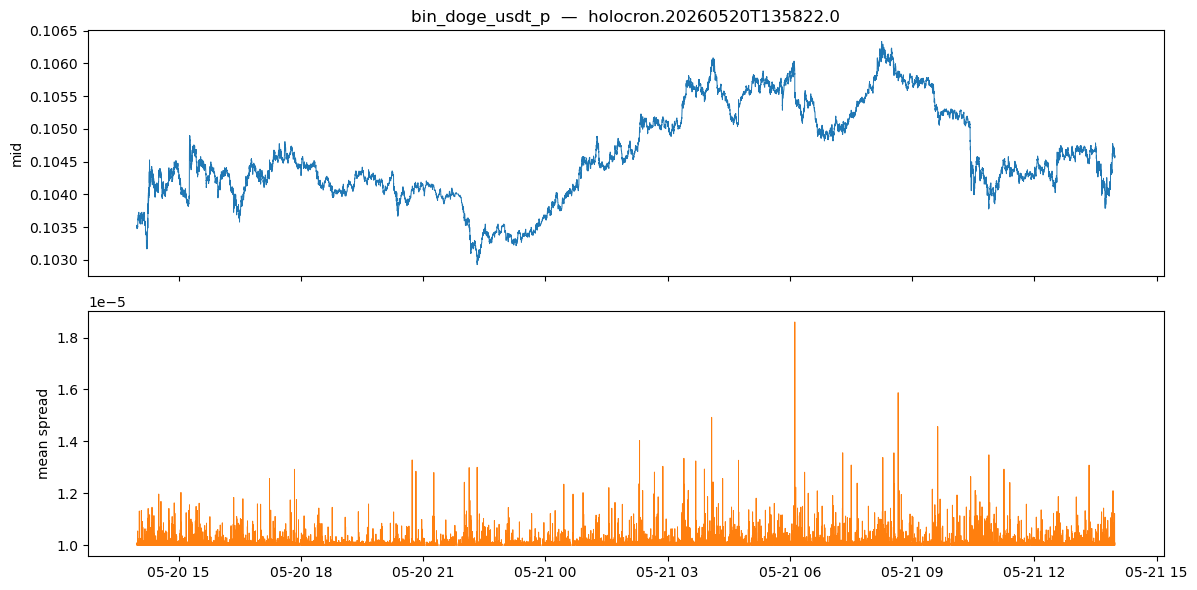

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(mid["rx_time"], mid["mid"], lw=0.7)
ax1.set_ylabel("mid")
ax1.set_title(f"{LISTING}  —  {BLOCK}")
ax2.plot(mid["rx_time"], mid["spread"], lw=0.7, color="C1")
ax2.set_ylabel("mean spread")
fig.tight_layout()